# POC 02 — Wyckoff Secondary-Test phase (arXiv:2403.18839v1, Listing 2)

Proof of concept for **Algorithm 2** of *Long Short-Term Memory Pattern Recognition in Currency
Trading* (Jai Pal, 2024) — the **Secondary Test (ST)** phase, the "equal lows" half of the
accumulation pattern — run against real **BTCUSDT** data.

| | |
|---|---|
| Paper | [`research/paper/wyckoff/2403.18839_LSTM_Wyckoff_Currency_Trading.pdf`](../../research/paper/wyckoff/2403.18839_LSTM_Wyckoff_Currency_Trading.pdf) |
| Spec / write-up | [`02_secondary_test_phase.md`](02_secondary_test_phase.md) |
| Previous POC | [`01_trading_range_phase.md`](01_trading_range_phase.md) · [`wychoff_poc.ipynb`](wychoff_poc.ipynb) |
| Scope | Listing 2 (ST generator) + Listing 3 (`filler` / `upFiller`). Listing 4 (LSTM) is still out of scope. |
| Data | Same BTCUSDT 4h / 180-bar slice as POC 01, so the two are directly comparable |

**The headline finding is a bug in the paper.** `upFiller` assigns `end_val = pattern[i+1]` and
never uses it, so `p4` — the second of the two retests the ST phase is *defined* by — is drawn,
clipped, and then silently discarded. The published ST model was trained on **one** retest, not two.

**Four figures:**

1. `fig4_st_pipeline.png` — the three assembly stages, and where `p4` vanishes.
2. `fig5_tolerance.png` — translating the paper's absolute `σ = 5` into a scale-free band.
3. `fig6_btcusdt_st.png` — the rule applied to BTCUSDT 4h. **← main output**
4. `fig7_accumulation.png` — TR + ST on one chart: the full accumulation pattern.

## 0 · Setup

Same palette and config as POC 01. Candles stay recessive; ST structures carry orange, TR aqua,
the swing chain blue.

In [1]:
# !pip install requests pandas numpy matplotlib
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.patches import Rectangle

# ----------------------------------------------------------------- config --
SYMBOL, INTERVAL, LIMIT = "BTCUSDT", "4h", 180
PCT         = 0.015   # ZigZag reversal threshold, carried over from POC 01
TOL_FRAC    = 0.15    # "equal lows": |p3 - p2| <= TOL_FRAC * (p1 - p2). See section 2.
BOUNCE_FRAC = 0.50    # the upFiller rally: bounce - p3 >= BOUNCE_FRAC * (p1 - p2)

IMG = Path("images"); IMG.mkdir(exist_ok=True)
CACHE = Path("data"); CACHE.mkdir(exist_ok=True)

# ---------------------------------------------------------------- palette --
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
S1_BLUE, S2_ORANGE, S3_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
HALO = dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none", alpha=0.85)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "text.color": INK, "axes.labelcolor": INK_2, "axes.edgecolor": AXIS,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
    "figure.dpi": 110,
})
print("ready")

ready


## 1 · Listings 2 and 3, ported verbatim

```python
# Listing 2 - Secondary Test generator (p.5)
def generate_pattern(validity):
    if validity:
        p1 = random.uniform(0, 100)     # range high
        p2 = random.uniform(0, p1)      # initial support low
        p3 = random.gauss(p2, 5)        # retest 1  - "equal low"
        p4 = random.gauss(p2, 5)        # retest 2  - "equal low"
        p3 = min(max(0, p3), p1)
        p4 = min(max(0, p4), p1)
        pattern1 = [validity, p1, p2]
        pattern2 = upFiller([p3, p4], p1)
        final_pattern = filler(pattern1 + pattern2)
        return final_pattern

# Listing 3 - noise injection (p.6)
def filler(pattern):
    new_pattern = [pattern[0]]
    num_fillers = 2
    for i in range(1, len(pattern) - 1):
        new_pattern.append(pattern[i])
        for _ in range(num_fillers):
            new_pattern.append(random.uniform(pattern[i], pattern[i+1]))
    new_pattern.append(pattern[-1])
    return new_pattern

def upFiller(pattern, upperLimit):
    new_pattern = []
    for i in range(len(pattern) - 1):
        start_val = pattern[i]
        new_pattern.append(start_val)
        end_val = pattern[i + 1]          # <-- assigned and NEVER used
        num_fillers = 1
        for _ in range(num_fillers):
            new_pattern.append(random.uniform(start_val, upperLimit))
    return new_pattern
```

### 🔴 `upFiller` discards `p4`

Trace `upFiller([p3, p4], p1)`. The loop runs `range(len(pattern) - 1)` = `range(1)`, so only
`i = 0`. It appends `pattern[0]` (= `p3`) and one filler drawn `U(p3, p1)`. It binds
`end_val = pattern[1]` (= `p4`) and **never reads it**, and unlike `filler` it never appends
`pattern[-1]` after the loop. Return value: `[p3, bounce]`.

`p4` is drawn, clipped to `[0, p1]` — and thrown away.

**Consequence:** the ST phase is defined by *multiple* equal lows, and the paper's own §2.2 says
"the creation of liquidity through uniform and equal lows". But the generator emits exactly two
lows — `p2` and `p3` — so the trained model never saw a third test. The 99.98% test accuracy is
for a **double bottom**, not the multi-test structure the text describes.

### Two other consequences worth naming

- **No invalid branch.** Listing 2 has no `if not validity:` case — the paper never prints how ST
  negatives were generated, though §6 reports 100,000 of them.
- **`filler` cannot overshoot.** `random.uniform(a, b)` accepts `a > b`, so every filler point
  lands strictly *between* consecutive swing points. The synthetic path is monotone between
  swings and never overshoots a level — real price does nothing of the sort.

In [2]:
def filler(pattern):
    """Listing 3, verbatim."""
    new_pattern = [pattern[0]]
    num_fillers = 2
    for i in range(1, len(pattern) - 1):
        new_pattern.append(pattern[i])
        for _ in range(num_fillers):
            new_pattern.append(random.uniform(pattern[i], pattern[i + 1]))
    new_pattern.append(pattern[-1])
    return new_pattern


def upFiller(pattern, upperLimit):
    """Listing 3, verbatim - including the unused end_val."""
    new_pattern = []
    for i in range(len(pattern) - 1):
        start_val = pattern[i]
        new_pattern.append(start_val)
        end_val = pattern[i + 1]          # noqa: F841  <- assigned, NEVER used
        num_fillers = 1
        for _ in range(num_fillers):
            new_pattern.append(random.uniform(start_val, upperLimit))
    return new_pattern


def generate_st(validity=True, rng=random):
    """Listing 2, verbatim. Returns (final_sequence, the four drawn points, upFiller output)."""
    p1 = rng.uniform(0, 100)
    p2 = rng.uniform(0, p1)
    p3 = rng.gauss(p2, 5)
    p4 = rng.gauss(p2, 5)
    p3 = min(max(0, p3), p1)
    p4 = min(max(0, p4), p1)
    pattern1 = [validity, p1, p2]
    pattern2 = upFiller([p3, p4], p1)
    return filler(pattern1 + pattern2), (p1, p2, p3, p4), pattern2


# --- demonstrate the bug ----------------------------------------------------
seq, (p1, p2, p3, p4), up = generate_st(True, random.Random(1))
print(f"drawn      p1={p1:.2f}  p2={p2:.2f}  p3={p3:.2f}  p4={p4:.2f}")
print(f"upFiller   {[round(v, 2) for v in up]}   <- length {len(up)}, p4 absent")
print(f"p4 present in upFiller output? {any(abs(v - p4) < 1e-12 for v in up)}")
print(f"final seq  {len(seq) - 1} price points (n_features for the ST model)")

print()
print("=> the generator draws 3 lows (p2, p3, p4) and keeps 2 (p2, p3):")
print("   the published ST model learned a double bottom, not a multi-test structure.")

drawn      p1=13.44  p2=11.39  p3=11.72  p4=7.56
upFiller   [11.72, 11.86]   <- length 2, p4 absent
p4 present in upFiller output? False
final seq  10 price points (n_features for the ST model)

=> the generator draws 3 lows (p2, p3, p4) and keeps 2 (p2, p3):
   the published ST model learned a double bottom, not a multi-test structure.


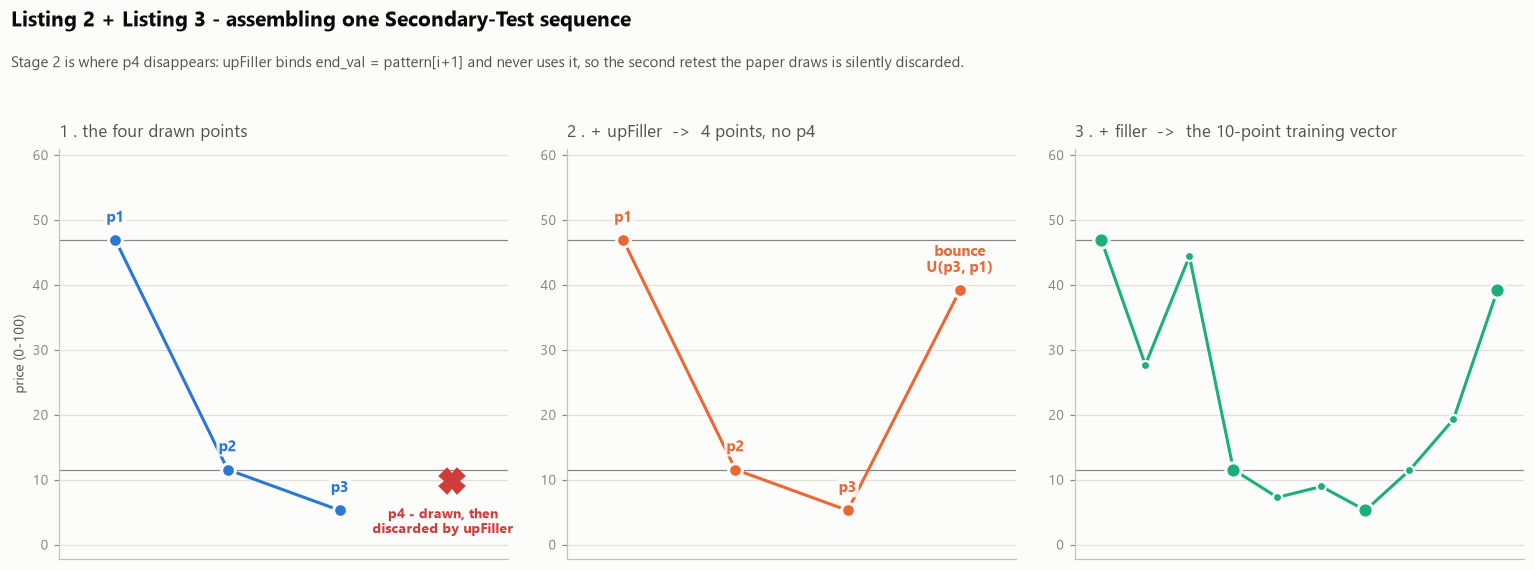

In [3]:
def fig_pipeline(seed=5):
    r = random.Random(seed)
    while True:
        seq, (p1, p2, p3, p4), up = generate_st(True, r)
        if p1 - p2 >= 35 and abs(p3 - p2) < 12:
            break
    stage2, final = [p1, p2] + up, seq[1:]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5.2))
    fig.suptitle("Listing 2 + Listing 3 - assembling one Secondary-Test sequence",
                 x=0.008, ha="left", fontsize=13.5, fontweight="bold", y=0.985)
    fig.text(0.008, 0.905,
             "Stage 2 is where p4 disappears: upFiller binds end_val = pattern[i+1] and never uses it, "
             "so the second retest the paper draws is silently discarded.",
             ha="left", fontsize=9.5, color=INK_2, va="top")

    ax = axes[0]
    ax.axhline(p1, color=MUTED, lw=0.8, zorder=1); ax.axhline(p2, color=MUTED, lw=0.8, zorder=1)
    ax.plot([1, 2, 3], [p1, p2, p3], "-o", color=S1_BLUE, lw=2, ms=9, mec=SURFACE, mew=2, zorder=3)
    ax.plot([4], [p4], "X", color=CRITICAL, ms=14, mew=2.5, zorder=4)
    ax.annotate("p4 - drawn, then\ndiscarded by upFiller", (4, p4), textcoords="offset points",
                xytext=(-6, -34), ha="center", fontsize=9, color=CRITICAL, fontweight="bold")
    for lbl, xx, yy in [("p1", 1, p1), ("p2", 2, p2), ("p3", 3, p3)]:
        ax.annotate(lbl, (xx, yy), textcoords="offset points", xytext=(0, 12), ha="center",
                    fontsize=9.5, fontweight="bold", color=S1_BLUE, bbox=HALO)
    ax.set_title("1 . the four drawn points", loc="left", fontsize=11, color=INK_2, pad=8)
    ax.set_xlim(0.5, 4.5)

    ax = axes[1]
    ax.axhline(p1, color=MUTED, lw=0.8, zorder=1); ax.axhline(p2, color=MUTED, lw=0.8, zorder=1)
    ax.plot(range(1, 5), stage2, "-o", color=S2_ORANGE, lw=2, ms=9, mec=SURFACE, mew=2, zorder=3)
    for lbl, xx in [("p1", 1), ("p2", 2), ("p3", 3), ("bounce\nU(p3, p1)", 4)]:
        ax.annotate(lbl, (xx, stage2[xx - 1]), textcoords="offset points", xytext=(0, 12),
                    ha="center", fontsize=9.5, fontweight="bold", color=S2_ORANGE, bbox=HALO)
    ax.set_title("2 . + upFiller  ->  4 points, no p4", loc="left", fontsize=11, color=INK_2, pad=8)
    ax.set_xlim(0.5, 4.5)

    ax = axes[2]
    ax.axhline(p1, color=MUTED, lw=0.8, zorder=1); ax.axhline(p2, color=MUTED, lw=0.8, zorder=1)
    xs = range(1, len(final) + 1)
    ax.plot(xs, final, "-", color=S3_AQUA, lw=2, zorder=3)
    ax.plot(xs, final, "o", color=S3_AQUA, ms=6, mec=SURFACE, mew=1.5, zorder=4)
    for k, xx in [(0, 1), (3, 4), (6, 7), (9, 10)]:
        ax.plot(xx, final[k], "o", color=S3_AQUA, ms=10, mec=SURFACE, mew=2, zorder=5)
    ax.set_title("3 . + filler  ->  the 10-point training vector", loc="left",
                 fontsize=11, color=INK_2, pad=8)
    ax.set_xlim(0.4, len(final) + 0.6)

    for ax in axes:
        ax.set_ylim(min(p2, p4) - 12, p1 + 14)
        ax.grid(axis="x", visible=False); ax.set_xticks([])
    axes[0].set_ylabel("price (0-100)")
    fig.tight_layout(rect=[0, 0, 1, 0.875])
    fig.savefig(IMG / "fig4_st_pipeline.png", dpi=150)
    return fig

fig_pipeline();

## 2 · Translating `σ = 5` into something a real chart can use

`p3 ~ gauss(p2, 5)` is an **absolute** spread on a hardcoded 0–100 axis. BTCUSDT trades near
63,000, so `σ = 5` cannot be carried over literally — it has to become a *relative* band.

The defensible translation is to express the retest gap as a fraction of the trading range,
which is scale-free:

$$\text{gap ratio} \;=\; \frac{|p_3 - p_2|}{p_1 - p_2}$$

Measuring that ratio over the generator's own draws gives the distribution the model was
actually trained against, and `TOL_FRAC` is then set to its median rather than guessed.

What the measurement exposes is that **`σ = 5` barely constrains anything**: `p1 - p2` is itself
random and uncontrolled, so the same absolute σ means "razor tight" for a wide range and "wider
than the whole range" for a narrow one — plus the `min(max(0, ·), p1)` clip fires on ~16% of
draws, and when it clips upward the supposed *equal low* is pinned to the range **high**.

median ratio 0.1632 | P(ratio>1) 6.5% | clipped up 7.74% | clipped down 7.93%


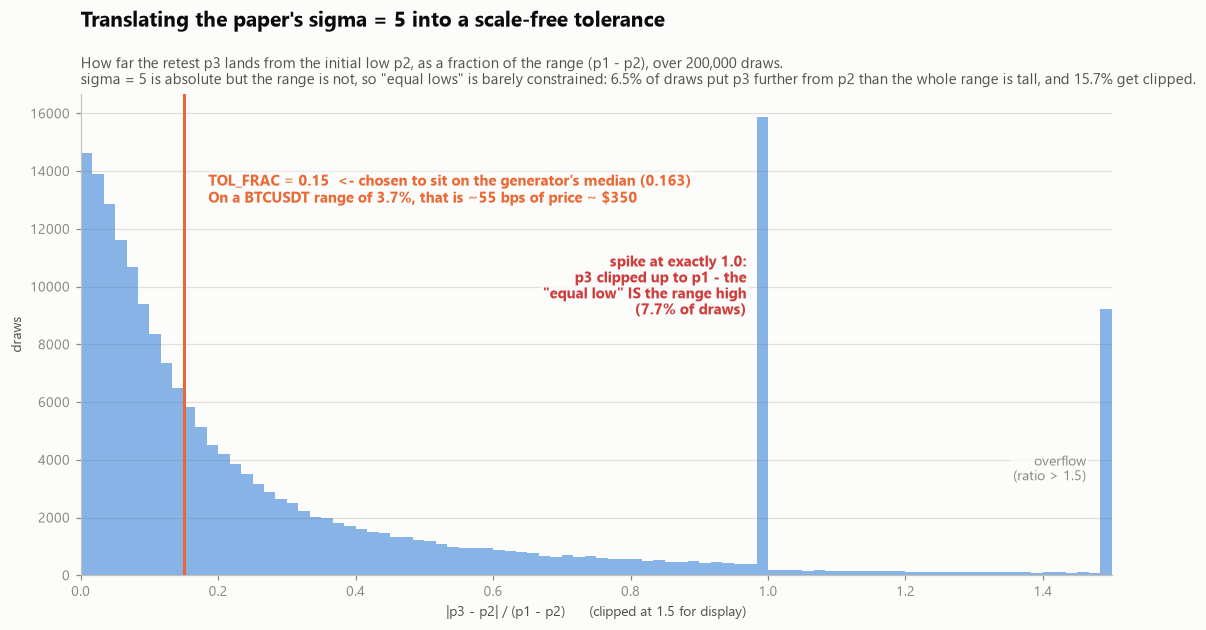

In [4]:
def fig_tolerance(n=200_000, seed=2, px_range_pct=0.037, price=63_000):
    r = random.Random(seed)
    ratios, clip_hi, clip_lo = [], 0, 0
    for _ in range(n):
        a = r.uniform(0, 100); b = r.uniform(0, a); g = r.gauss(b, 5)
        if a - b <= 1e-9:
            continue
        if g > a: clip_hi += 1
        if g < 0: clip_lo += 1
        ratios.append(abs(min(max(0, g), a) - b) / (a - b))
    ratios = np.array(ratios)
    med, over = float(np.median(ratios)), float((ratios > 1).mean())
    chi, clo = clip_hi / len(ratios), clip_lo / len(ratios)

    fig, ax = plt.subplots(figsize=(11.5, 5.8))
    ax.hist(np.clip(ratios, 0, 1.5), bins=90, color=S1_BLUE, alpha=0.55, edgecolor="none")
    ax.axvline(TOL_FRAC, color=S2_ORANGE, lw=2, zorder=4)
    bps = TOL_FRAC * px_range_pct * 10_000
    ax.annotate(f"TOL_FRAC = {TOL_FRAC}  <- chosen to sit on the generator's median ({med:.3f})\n"
                f"On a BTCUSDT range of {px_range_pct:.1%}, that is ~{bps:.0f} bps of price ~ "
                f"${TOL_FRAC*px_range_pct*price:,.0f}",
                (TOL_FRAC, 0.80), xycoords=("data", "axes fraction"), textcoords="offset points",
                xytext=(16, 0), ha="left", va="center", fontsize=9.5, fontweight="bold",
                color=S2_ORANGE, bbox=HALO, zorder=5)
    ax.annotate(f"spike at exactly 1.0:\np3 clipped up to p1 - the\n\"equal low\" IS the range high\n({chi:.1%} of draws)",
                (1.0, 0.60), xycoords=("data", "axes fraction"), textcoords="offset points",
                xytext=(-14, 0), ha="right", va="center", fontsize=9.5, color=CRITICAL,
                fontweight="bold", bbox=HALO, zorder=5)
    ax.annotate("overflow\n(ratio > 1.5)", (1.485, 0.22), xycoords=("data", "axes fraction"),
                textcoords="offset points", xytext=(-10, 0), ha="right", va="center",
                fontsize=9, color=MUTED, bbox=HALO, zorder=5)

    ax.set_title("Translating the paper's sigma = 5 into a scale-free tolerance",
                 loc="left", fontsize=13.5, fontweight="bold", pad=44)
    ax.annotate("How far the retest p3 lands from the initial low p2, as a fraction of the range (p1 - p2), over 200,000 draws.\n"
                f"sigma = 5 is absolute but the range is not, so \"equal lows\" is barely constrained: "
                f"{over:.1%} of draws put p3 further from p2 than the whole range is tall, and {chi+clo:.1%} get clipped.",
                xy=(0, 1.012), xycoords="axes fraction", fontsize=9.5, color=INK_2, va="bottom")
    ax.set_xlabel("|p3 - p2| / (p1 - p2)      (clipped at 1.5 for display)")
    ax.set_ylabel("draws"); ax.set_xlim(0, 1.5); ax.grid(axis="x", visible=False)
    fig.tight_layout()
    fig.savefig(IMG / "fig5_tolerance.png", dpi=150)
    print(f"median ratio {med:.4f} | P(ratio>1) {over:.1%} | clipped up {chi:.2%} | clipped down {clo:.2%}")
    return fig

fig_tolerance();

## 3 · Detecting ST on a real swing chain

Same ZigZag bridge as POC 01. The ST sequence in the paper is
`p1 (high) → p2 (low) → p3 (low) → bounce (high)`, so on a strictly alternating swing chain it
maps to a **5-swing window** `H, L, H, L, H`:

$$(p_1,\; p_2,\; \text{mid},\; p_3,\; \text{bounce})$$

with two gates, one per surviving generator constraint:

| Gate | From | Test |
|---|---|---|
| **equal lows** | `p3 ~ gauss(p2, 5)` | $\lvert p_3 - p_2\rvert \le$ `TOL_FRAC` $\times (p_1 - p_2)$ |
| **the rally** | `upFiller` draws `U(p3, p1)` | $\text{bounce} - p_3 \ge$ `BOUNCE_FRAC` $\times (p_1 - p_2)$ |

`mid` — the swing high between the two lows — is deliberately **not** gated. In the generator
that stretch is produced by `filler`, and §4.2 of the paper explicitly calls filler points *noise*
introduced for generalisation, not structure. It is kept as a diagnostic only.

> Note the mismatch this exposes: `filler` draws `U(p2, p3)` between the two lows, so the paper's
> synthetic path never leaves the tolerance band between retests. A ZigZag chain **must** put a
> swing high there, at least `PCT` above the low. The paper's noise model and a swing
> representation are structurally incompatible — gating on `mid` at the same tolerance yields
> **zero** detections, which the diagnostic below confirms.

In [5]:
def fetch_klines(symbol=SYMBOL, interval=INTERVAL, limit=LIMIT, use_cache=True):
    """Binance public spot klines, cached to data/. Shared with POC 01."""
    f = CACHE / f"{symbol}_{interval}_{limit}.csv"
    if use_cache and f.exists():
        print(f"loaded cache {f}")
        return pd.read_csv(f, parse_dates=["open_time"])
    r = requests.get("https://api.binance.com/api/v3/klines",
                     params={"symbol": symbol, "interval": interval, "limit": limit}, timeout=20)
    r.raise_for_status()
    cols = ["open_time", "open", "high", "low", "close", "volume", "close_time",
            "qav", "trades", "tbb", "tbq", "ignore"]
    df = pd.DataFrame(r.json(), columns=cols)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    df = df[["open_time", "open", "high", "low", "close", "volume"]].reset_index(drop=True)
    df.to_csv(f, index=False)
    return df


def zigzag_swings(high, low, pct=PCT):
    """Percentage-reversal ZigZag -> alternating (index, price, H|L). Carried over from POC 01."""
    high, low = np.asarray(high, float), np.asarray(low, float)
    piv = []
    hi_i, hi_p, lo_i, lo_p, trend = 0, high[0], 0, low[0], 0
    for i in range(1, len(high)):
        if high[i] > hi_p: hi_i, hi_p = i, high[i]
        if low[i] < lo_p:  lo_i, lo_p = i, low[i]
        if trend >= 0 and low[i] <= hi_p * (1 - pct):
            piv.append((hi_i, hi_p, "H")); trend = -1
            j = hi_i + int(np.argmin(low[hi_i:i + 1])); lo_i, lo_p = j, low[j]
        elif trend <= 0 and high[i] >= lo_p * (1 + pct):
            piv.append((lo_i, lo_p, "L")); trend = 1
            j = lo_i + int(np.argmax(high[lo_i:i + 1])); hi_i, hi_p = j, high[j]
    return piv


def tr_rule(p1, p2, p3, p4):
    """POC 01's Listing 1 rule, for the combined accumulation chart."""
    return (p1 > p2) and (p2 < p3) and (p4 < p3) and (p3 < p1) and (p4 > p2)


def scan_tr(piv):
    out = []
    for s in range(len(piv) - 3):
        w = piv[s:s + 4]
        if [k for _, _, k in w] != ["H", "L", "H", "L"]:
            continue
        p1, p2, p3, p4 = [p for _, p, _ in w]
        out.append({"idx": [i for i, _, _ in w], "pts": [p1, p2, p3, p4],
                    "valid": bool(tr_rule(p1, p2, p3, p4))})
    return out


def scan_st(piv, tol=TOL_FRAC, bounce_f=BOUNCE_FRAC, interior=0.50):
    """5-swing window H,L,H,L,H = (p1, p2, mid, p3, bounce)."""
    out = []
    for s in range(len(piv) - 4):
        w = piv[s:s + 5]
        if [k for _, _, k in w] != ["H", "L", "H", "L", "H"]:
            continue
        p1, p2, mid, p3, bounce = [p for _, p, _ in w]
        rng_h = p1 - p2
        if rng_h <= 0:
            continue
        c_eq = abs(p3 - p2) <= tol * rng_h              # gauss(p2, 5)      -> equal lows
        c_bo = (bounce - p3) >= bounce_f * rng_h        # upFiller U(p3,p1) -> the rally
        c_in = (mid - p2) <= interior * rng_h           # DIAGNOSTIC ONLY (filler == noise)
        out.append({"idx": [i for i, _, _ in w], "pts": [p1, p2, mid, p3, bounce],
                    "range": rng_h, "gap": abs(p3 - p2),
                    "eq": c_eq, "bounce": c_bo, "interior": c_in,
                    "valid": bool(c_eq and c_bo)})
    return out

In [6]:
df   = fetch_klines()
piv  = zigzag_swings(df["high"], df["low"], PCT)
sts  = scan_st(piv)
trs  = scan_tr(piv)
valid = [w for w in sts if w["valid"]]

print(f"{SYMBOL} {INTERVAL} | {len(df)} bars | {df.open_time.iloc[0]:%Y-%m-%d %H:%M} -> {df.open_time.iloc[-1]:%Y-%m-%d %H:%M}")
print(f"swings = {len(piv)}   H-led 5-swing windows = {len(sts)}   valid ST = {len(valid)}")
print(f"   pass equal-lows gate : {sum(w['eq'] for w in sts)}")
print(f"   pass rally gate      : {sum(w['bounce'] for w in sts)}")
print()
print("diagnostics on the un-gated interior swing high:")
print(f"   interior stays in lower 50% of range      : {sum(w['interior'] for w in sts)} / {len(sts)}")
strict = sum(w['eq'] and w['bounce'] and (w['pts'][2] - w['pts'][1]) <= TOL_FRAC * w['range'] for w in sts)
print(f"   interior inside the tolerance band itself : {strict} / {len(sts)}   <- the paper's filler taken literally")
print()
for k, w in enumerate(valid, start=1):
    p1, p2, mid, p3, bo = w["pts"]
    print(f"ST #{k}  {df.open_time.iloc[w['idx'][1]]:%m-%d %H:%M} -> {df.open_time.iloc[w['idx'][4]]:%m-%d %H:%M}   "
          f"p2={p2:,.0f}  p3={p3:,.0f}  gap={w['gap']:,.0f} ({w['gap']/w['range']:.1%} of range)  "
          f"bounce={bo:,.0f}")

loaded cache data\BTCUSDT_4h_180.csv
BTCUSDT 4h | 180 bars | 2026-07-10 12:00 -> 2026-08-09 08:00
swings = 34   H-led 5-swing windows = 15   valid ST = 2
   pass equal-lows gate : 2
   pass rally gate      : 13

diagnostics on the un-gated interior swing high:
   interior stays in lower 50% of range      : 1 / 15
   interior inside the tolerance band itself : 0 / 15   <- the paper's filler taken literally

ST #1  07-24 12:00 -> 07-27 20:00   p2=63,740  p3=63,606  gap=134 (6.5% of range)  bounce=65,056
ST #2  07-31 12:00 -> 08-02 20:00   p2=62,466  p3=62,275  gap=191 (6.5% of range)  bounce=63,796


In [7]:
# Both free parameters at once - neither exists in the paper.
rows = []
for t in [0.05, 0.10, 0.15, 0.20, 0.30]:
    row = {"TOL_FRAC": f"{t:.2f}"}
    for b in [0.25, 0.50, 0.75]:
        row[f"bounce>={b:.2f}"] = sum(w["valid"] for w in scan_st(piv, tol=t, bounce_f=b))
    rows.append(row)
pd.DataFrame(rows).set_index("TOL_FRAC")

,bounce>=0.25,bounce>=0.50,bounce>=0.75
TOL_FRAC,,,
0.05,0,0,0
0.10,2,2,0
0.15,2,2,0
0.20,3,3,1
0.30,3,3,1


## 4 · The main output — Listing 2 applied to BTCUSDT

The orange band is the support zone: $p_2 \pm$ `TOL_FRAC` $\times$ range. Both lows have to sit
inside it for the window to count as equal lows.

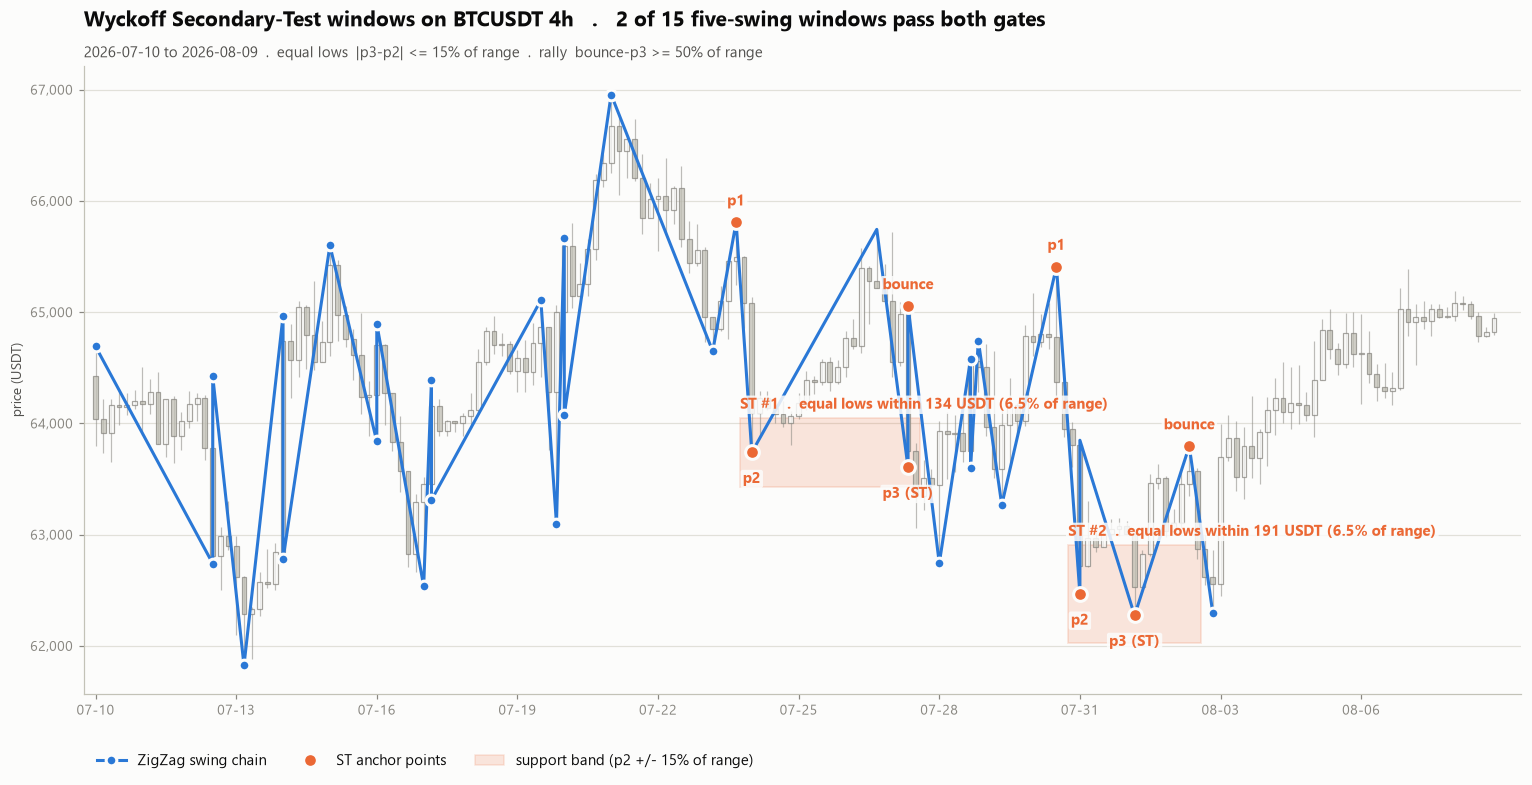

In [8]:
def _candles(ax, df, x):
    up = df["close"] >= df["open"]
    ax.vlines(x, df["low"], df["high"], color=MUTED, lw=0.8, alpha=0.55, zorder=2)
    for mask, fc in [(up, SURFACE), (~up, AXIS)]:
        sub, xs = df[mask], x[mask.values]
        ax.bar(xs, (sub["close"] - sub["open"]).abs().clip(lower=1e-9),
               bottom=sub[["open", "close"]].min(axis=1), width=0.62,
               facecolor=fc, edgecolor=MUTED, linewidth=0.8, alpha=0.75, zorder=3)


def _timeaxis(ax, df, n):
    ticks = list(range(0, n, max(1, n // 10)))
    ax.set_xticks(ticks); ax.set_xticklabels([f"{df['open_time'].iloc[i]:%m-%d}" for i in ticks])
    ax.set_ylabel("price (USDT)"); ax.set_xlim(-1.5, n + 2.5)
    ax.grid(axis="x", visible=False)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")


def fig_st_chart(df, piv, sts):
    n = len(df); x = np.arange(n)
    fig, ax = plt.subplots(figsize=(14, 7.2))
    _candles(ax, df, x)

    valid = [w for w in sts if w["valid"]]
    for k, w in enumerate(valid, start=1):
        p1, p2, mid, p3, bounce = w["pts"]
        half = TOL_FRAC * w["range"]
        i1, i4 = w["idx"][1], w["idx"][4]
        ax.add_patch(Rectangle((i1 - 1.5, p2 - half), (i4 - i1) + 3, 2 * half,
                               facecolor=S2_ORANGE, alpha=0.16, edgecolor=S2_ORANGE,
                               linewidth=1.2, zorder=1))
        ax.annotate(f"ST #{k}  .  equal lows within {w['gap']:,.0f} USDT ({w['gap']/w['range']:.1%} of range)",
                    (i1 - 1.5, p2 + half), textcoords="offset points", xytext=(0, 6),
                    ha="left", fontsize=9.5, fontweight="bold", color=S2_ORANGE, zorder=7, bbox=HALO)
        for lbl, i, p, dy in [("p1", w["idx"][0], p1, 11), ("p2", i1, p2, -20),
                              ("p3 (ST)", w["idx"][3], p3, -20), ("bounce", i4, bounce, 11)]:
            ax.plot(i, p, "o", color=S2_ORANGE, ms=9, mec=SURFACE, mew=2, zorder=6)
            ax.annotate(lbl, (i, p), textcoords="offset points", xytext=(0, dy), ha="center",
                        fontsize=9.5, fontweight="bold", color=S2_ORANGE, zorder=7, bbox=HALO)

    pi = [i for i, _, _ in piv]; pp = [p for _, p, _ in piv]
    ax.plot(pi, pp, "-", color=S1_BLUE, lw=2, zorder=4)
    used = {i for w in valid for i in w["idx"]}
    ax.plot([i for i in pi if i not in used], [p for i, p in zip(pi, pp) if i not in used],
            "o", color=S1_BLUE, ms=7, mec=SURFACE, mew=2, zorder=5)

    t0, t1 = df["open_time"].iloc[0], df["open_time"].iloc[-1]
    ax.set_title(f"Wyckoff Secondary-Test windows on {SYMBOL} {INTERVAL}   .   "
                 f"{len(valid)} of {len(sts)} five-swing windows pass both gates",
                 loc="left", fontsize=13.5, fontweight="bold", pad=26)
    ax.annotate(f"{t0:%Y-%m-%d} to {t1:%Y-%m-%d}  .  equal lows  |p3-p2| <= {TOL_FRAC:.0%} of range  .  "
                f"rally  bounce-p3 >= {BOUNCE_FRAC:.0%} of range",
                xy=(0, 1.014), xycoords="axes fraction", fontsize=9.5, color=INK_2)
    _timeaxis(ax, df, n)
    h = [plt.Line2D([], [], color=S1_BLUE, lw=2, marker="o", ms=7, mec=SURFACE, mew=2),
         plt.Line2D([], [], color=S2_ORANGE, lw=0, marker="o", ms=9, mec=SURFACE, mew=2),
         Rectangle((0, 0), 1, 1, facecolor=S2_ORANGE, alpha=0.16, edgecolor=S2_ORANGE)]
    ax.legend(h, ["ZigZag swing chain", "ST anchor points",
                  f"support band (p2 +/- {TOL_FRAC:.0%} of range)"],
              loc="upper left", frameon=False, fontsize=9.5, ncols=3, bbox_to_anchor=(0, -0.075))
    fig.tight_layout()
    fig.savefig(IMG / "fig6_btcusdt_st.png", dpi=150)
    return fig

fig_st_chart(df, piv, sts);

## 5 · Both halves of the accumulation pattern

The paper frames TR and ST as consecutive stages of a single accumulation. Detected
independently on the same swing chain, they are **not** mutually exclusive — a contracting range
whose second low happens to land near the first satisfies both definitions at once.

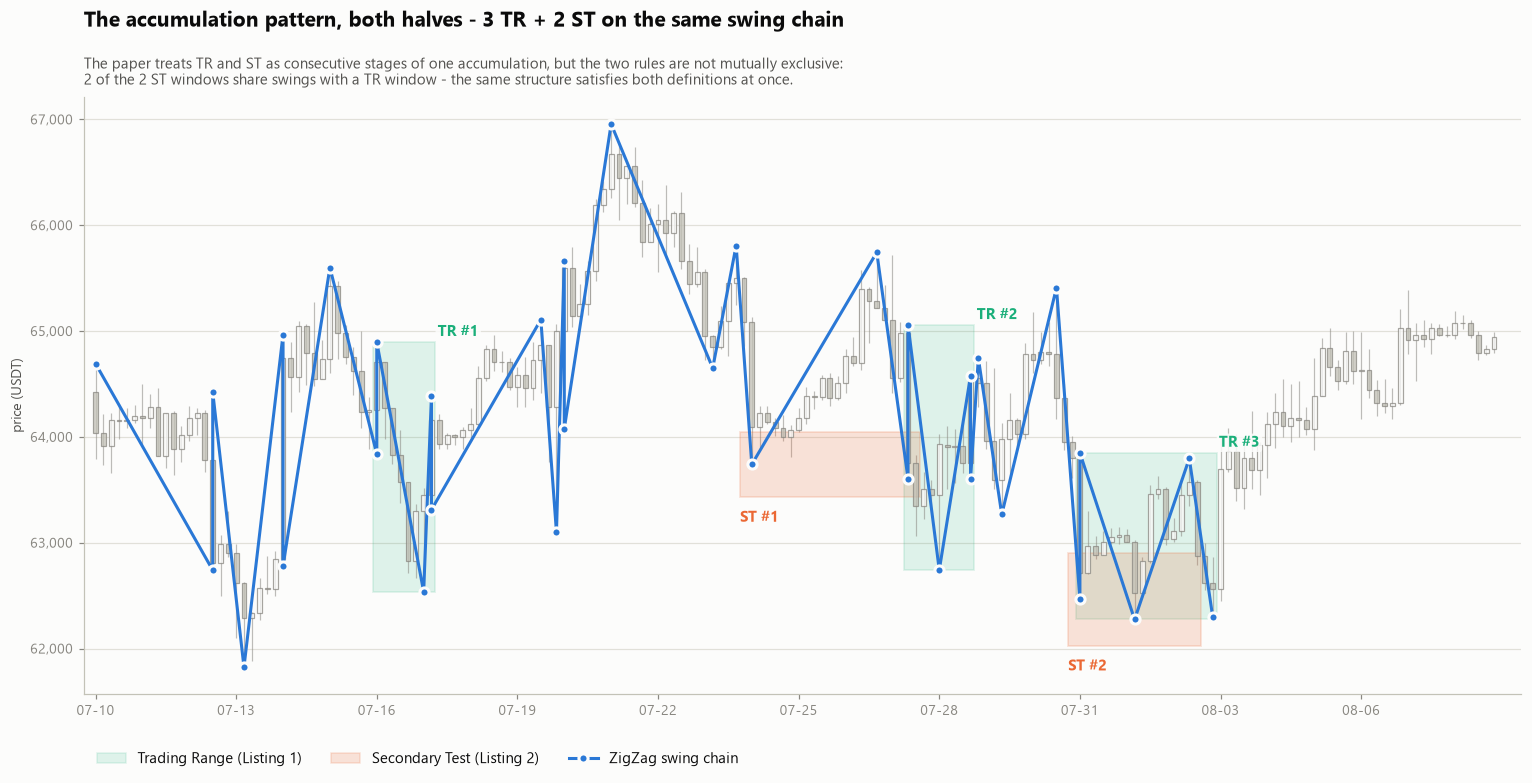

In [9]:
def fig_accumulation(df, piv, trs, sts):
    n = len(df); x = np.arange(n)
    fig, ax = plt.subplots(figsize=(14, 7.2))
    _candles(ax, df, x)

    vt = [w for w in trs if w["valid"]]; vs = [w for w in sts if w["valid"]]
    for k, w in enumerate(vt, start=1):
        i0, i3 = w["idx"][0], w["idx"][3]
        p1, p2 = w["pts"][0], w["pts"][1]
        ax.add_patch(Rectangle((i0 - 0.5, p2), (i3 - i0) + 1, p1 - p2, facecolor=S3_AQUA,
                               alpha=0.13, edgecolor=S3_AQUA, linewidth=1.2, zorder=1))
        ax.annotate(f"TR #{k}", (i3 + 0.8, p1), textcoords="offset points", xytext=(0, 4),
                    ha="left", fontsize=9.5, fontweight="bold", color=S3_AQUA, zorder=7, bbox=HALO)
    for k, w in enumerate(vs, start=1):
        p2, half = w["pts"][1], TOL_FRAC * w["range"]
        i1, i4 = w["idx"][1], w["idx"][4]
        ax.add_patch(Rectangle((i1 - 1.5, p2 - half), (i4 - i1) + 3, 2 * half,
                               facecolor=S2_ORANGE, alpha=0.18, edgecolor=S2_ORANGE,
                               linewidth=1.2, zorder=2))
        ax.annotate(f"ST #{k}", (i1 - 1.5, p2 - half), textcoords="offset points", xytext=(0, -16),
                    ha="left", fontsize=9.5, fontweight="bold", color=S2_ORANGE, zorder=7, bbox=HALO)

    pi = [i for i, _, _ in piv]; pp = [p for _, p, _ in piv]
    ax.plot(pi, pp, "-", color=S1_BLUE, lw=2, zorder=4)
    ax.plot(pi, pp, "o", color=S1_BLUE, ms=6, mec=SURFACE, mew=2, zorder=5)

    shared = sum(1 for a in vt for b in vs if set(a["idx"]) & set(b["idx"]))
    ax.set_title(f"The accumulation pattern, both halves - {len(vt)} TR + {len(vs)} ST on the same swing chain",
                 loc="left", fontsize=13.5, fontweight="bold", pad=46)
    ax.annotate("The paper treats TR and ST as consecutive stages of one accumulation, but the two rules are not "
                f"mutually exclusive:\n{shared} of the {len(vs)} ST windows share swings with a TR window - the same "
                "structure satisfies both definitions at once.",
                xy=(0, 1.014), xycoords="axes fraction", fontsize=9.5, color=INK_2, va="bottom")
    _timeaxis(ax, df, n)
    ax.legend([Rectangle((0, 0), 1, 1, facecolor=S3_AQUA, alpha=0.13, edgecolor=S3_AQUA),
               Rectangle((0, 0), 1, 1, facecolor=S2_ORANGE, alpha=0.18, edgecolor=S2_ORANGE),
               plt.Line2D([], [], color=S1_BLUE, lw=2, marker="o", ms=6, mec=SURFACE, mew=2)],
              ["Trading Range (Listing 1)", "Secondary Test (Listing 2)", "ZigZag swing chain"],
              loc="upper left", frameon=False, fontsize=9.5, ncols=3, bbox_to_anchor=(0, -0.075))
    fig.tight_layout()
    fig.savefig(IMG / "fig7_accumulation.png", dpi=150)
    return fig

fig_accumulation(df, piv, trs, sts);

## 6 · What this POC establishes

1. **`upFiller` discards `p4`.** The second retest is drawn, clipped, and thrown away because
   `end_val` is bound and never read, and the final element is never appended. The published ST
   model — the one reporting **99.98%** accuracy — was trained on a **two-low double bottom**,
   not the multi-test structure §2.2 describes. This is a defect in the artifact, not a
   simplification of it.

2. **`σ = 5` is not a tolerance, it is an accident of scale.** Because `p1 - p2` is itself random,
   the same absolute σ means wildly different things per draw: the gap ratio's median is 0.163 but
   6.5% of draws place the "equal low" further from `p2` than the entire range is tall. The
   `min(max(0, ·), p1)` clip fires on ~15.7% of draws, and on 7.7% it pins the supposed equal
   **low** to the range **high**. Any real implementation must replace σ with a relative band.

3. **The paper's noise model is incompatible with a swing representation.** `filler` draws
   `U(p2, p3)` between the two lows, so the synthetic path never leaves the tolerance band between
   retests — while any ZigZag chain must place a swing high there. Gating on that stretch at the
   paper's own tolerance yields **zero** detections. The generator does not produce sequences a
   swing detector could have produced.

4. **TR and ST are not mutually exclusive.** On the same swing chain, ST #2 and TR #3 fire on
   overlapping swings. Wyckoff treats them as ordered stages; the rules as written carry no
   ordering, no state, and no memory of which stage came before.

5. **Two more free parameters, still none from the paper.** `TOL_FRAC` and `BOUNCE_FRAC` join
   POC 01's `PCT`. The sweep in §3 shows detections moving 0 → 3 across plausible settings. The
   paper contributes the *shape*; every number that makes it operational is supplied downstream.

6. **ST is rarer than TR here** — 2 vs 3 detections, and only 2 of 15 windows clear the equal-lows
   gate. That is the expected direction: an equal-low retest is a stricter condition than a
   contracting range.

**Next**: Listing 4 (the LSTM), or the tradeability test. See
[`02_secondary_test_phase.md`](02_secondary_test_phase.md) § Next steps.